# Errores ARIMA


Este notebook recalcula MAE, RMSE y MAPE para los forecasts ARIMA exportados por `05_arima_baseline.ipynb`. Lee archivos con contrato `timestamp,y,yhat` desde `notebooks/artifacts/arima/`, resume los tramos evaluados y guarda las metricas en `notebooks/artifacts/comparison/`.


Importamos las dependencias necesarias para leer forecasts, calcular metricas, exportar tablas y graficar resultados.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)


Definimos el dataset, las rutas de artifacts y los cuatro horizontes ARIMA que deben existir despues de ejecutar el notebook baseline.


In [2]:
DATASET_NAME = "AT"
NOTEBOOK_DIR = Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"
ARTIFACTS_DIR = NOTEBOOK_DIR / "artifacts"
ARIMA_DIR = ARTIFACTS_DIR / "arima"
OUTPUT_DIR = ARTIFACTS_DIR / "comparison"

EXPERIMENTS = [
    {"name": "daily", "label": "24 horas", "horizon": 24},
    {"name": "weekly", "label": "168 horas", "horizon": 168},
    {"name": "biweekly", "label": "336 horas", "horizon": 336},
    {"name": "monthly", "label": "720 horas", "horizon": 720},
]

ARIMA_DIR, OUTPUT_DIR


(PosixPath('/home/albert/projects/nbeats-forecasting/notebooks/artifacts/arima'),
 PosixPath('/home/albert/projects/nbeats-forecasting/notebooks/artifacts/comparison'))

Estas funciones cargan forecasts ARIMA con el contrato comun y calculan las metricas de error usadas en la comparacion.


In [3]:
def forecast_metrics(actual: pd.Series, predicted: pd.Series) -> dict[str, float]:
    actual_values = actual.astype(float).to_numpy()
    predicted_values = predicted.astype(float).to_numpy()
    errors = actual_values - predicted_values
    nonzero_mask = actual_values != 0
    mape = np.nan if not nonzero_mask.any() else np.mean(np.abs(errors[nonzero_mask] / actual_values[nonzero_mask])) * 100

    return {
        "mae": float(np.mean(np.abs(errors))),
        "rmse": float(np.sqrt(np.mean(errors**2))),
        "mape": float(mape),
    }

def load_arima_forecast(path: Path, experiment: dict) -> pd.DataFrame:
    forecast = pd.read_csv(path)
    required_columns = {"timestamp", "y", "yhat"}
    missing_columns = required_columns.difference(forecast.columns)
    if missing_columns:
        missing = ", ".join(sorted(missing_columns))
        raise ValueError(f"{path} no tiene columnas requeridas: {missing}")

    forecast = forecast.loc[:, ["timestamp", "y", "yhat"]].copy()
    forecast["timestamp"] = pd.to_datetime(forecast["timestamp"], utc=True, errors="coerce")
    forecast["y"] = pd.to_numeric(forecast["y"], errors="coerce")
    forecast["yhat"] = pd.to_numeric(forecast["yhat"], errors="coerce")
    forecast = forecast.dropna(subset=["timestamp", "y", "yhat"]).sort_values("timestamp").reset_index(drop=True)

    if len(forecast) != experiment["horizon"]:
        raise ValueError(f"{path} tiene {len(forecast)} filas, se esperaban {experiment['horizon']}")

    forecast["dataset"] = DATASET_NAME
    forecast["model"] = "ARIMA"
    forecast["experiment"] = experiment["name"]
    forecast["label"] = experiment["label"]
    forecast["horizon"] = experiment["horizon"]
    forecast["source_path"] = str(path.relative_to(NOTEBOOK_DIR))
    return forecast


Cargamos los forecasts ARIMA disponibles. Si falta alguno, se registra para que sea visible sin detener el calculo de los demas horizontes.


In [4]:
forecasts = []
missing_files = []

for experiment in EXPERIMENTS:
    path = ARIMA_DIR / f"{DATASET_NAME.lower()}_arima_{experiment['name']}_h{experiment['horizon']}_forecast.csv"
    if not path.exists():
        missing_files.append({"model": "ARIMA", "experiment": experiment["name"], "path": str(path.relative_to(NOTEBOOK_DIR))})
        continue
    forecasts.append(load_arima_forecast(path, experiment))

if not forecasts:
    raise FileNotFoundError("No se encontraron forecasts ARIMA. Ejecuta primero 05_arima_baseline.ipynb.")

loaded_summary = pd.DataFrame([
    {
        "experiment": forecast["experiment"].iloc[0],
        "horizon": int(forecast["horizon"].iloc[0]),
        "rows": len(forecast),
        "start": forecast["timestamp"].iloc[0],
        "end": forecast["timestamp"].iloc[-1],
        "source_path": forecast["source_path"].iloc[0],
    }
    for forecast in forecasts
])
loaded_summary


,experiment,horizon,rows,start,end,source_path
0,daily,24,24,2019-01-08 00:00:00+00:00,2019-01-08 23:00:00+00:00,artifacts/arima/at_arima_daily_h24_forecast.csv
1,weekly,168,168,2019-01-29 00:00:00+00:00,2019-02-04 23:00:00+00:00,artifacts/arima/at_arima_weekly_h168_forecast.csv
2,biweekly,336,336,2019-02-26 00:00:00+00:00,2019-03-11 23:00:00+00:00,artifacts/arima/at_arima_biweekly_h336_forecas...
3,monthly,720,720,2019-04-01 00:00:00+00:00,2019-04-30 23:00:00+00:00,artifacts/arima/at_arima_monthly_h720_forecast...


Calculamos las metricas por horizonte usando los valores reales y pronosticados de cada forecast ARIMA.


In [5]:
metric_rows = []

for forecast in forecasts:
    metrics = forecast_metrics(forecast["y"], forecast["yhat"])
    metric_rows.append({
        "dataset": forecast["dataset"].iloc[0],
        "model": forecast["model"].iloc[0],
        "experiment": forecast["experiment"].iloc[0],
        "label": forecast["label"].iloc[0],
        "horizon": int(forecast["horizon"].iloc[0]),
        "test_rows": len(forecast),
        "test_start": forecast["timestamp"].iloc[0].isoformat(),
        "test_end": forecast["timestamp"].iloc[-1].isoformat(),
        "source_path": forecast["source_path"].iloc[0],
        **metrics,
    })

metrics_df = pd.DataFrame(metric_rows).sort_values("horizon").reset_index(drop=True)
metrics_df


,dataset,model,experiment,label,horizon,test_rows,test_start,test_end,source_path,mae,rmse,mape
0,AT,ARIMA,daily,24 horas,24,24,2019-01-08T00:00:00+00:00,2019-01-08T23:00:00+00:00,artifacts/arima/at_arima_daily_h24_forecast.csv,281.368702,306.124213,3.128593
1,AT,ARIMA,weekly,168 horas,168,168,2019-01-29T00:00:00+00:00,2019-02-04T23:00:00+00:00,artifacts/arima/at_arima_weekly_h168_forecast.csv,603.672731,789.265807,7.665130
2,AT,ARIMA,biweekly,336 horas,336,336,2019-02-26T00:00:00+00:00,2019-03-11T23:00:00+00:00,artifacts/arima/at_arima_biweekly_h336_forecas...,499.690773,743.039761,7.127308
3,AT,ARIMA,monthly,720 horas,720,720,2019-04-01T00:00:00+00:00,2019-04-30T23:00:00+00:00,artifacts/arima/at_arima_monthly_h720_forecast...,842.682797,1046.874870,11.602949


Exportamos las metricas ARIMA y el listado de archivos faltantes para usarlos despues en la comparacion final.


In [6]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
metrics_path = OUTPUT_DIR / f"{DATASET_NAME.lower()}_arima_error_metrics.csv"
missing_path = OUTPUT_DIR / f"{DATASET_NAME.lower()}_arima_missing_forecasts.csv"

metrics_df.to_csv(metrics_path, index=False)
pd.DataFrame(missing_files).to_csv(missing_path, index=False)

print(f"metrics: {metrics_path.relative_to(NOTEBOOK_DIR)}")
print(f"missing: {missing_path.relative_to(NOTEBOOK_DIR)}")


metrics: artifacts/comparison/at_arima_error_metrics.csv
missing: artifacts/comparison/at_arima_missing_forecasts.csv


Graficamos cada forecast ARIMA contra sus valores reales para revisar visualmente la escala y el tramo evaluado.


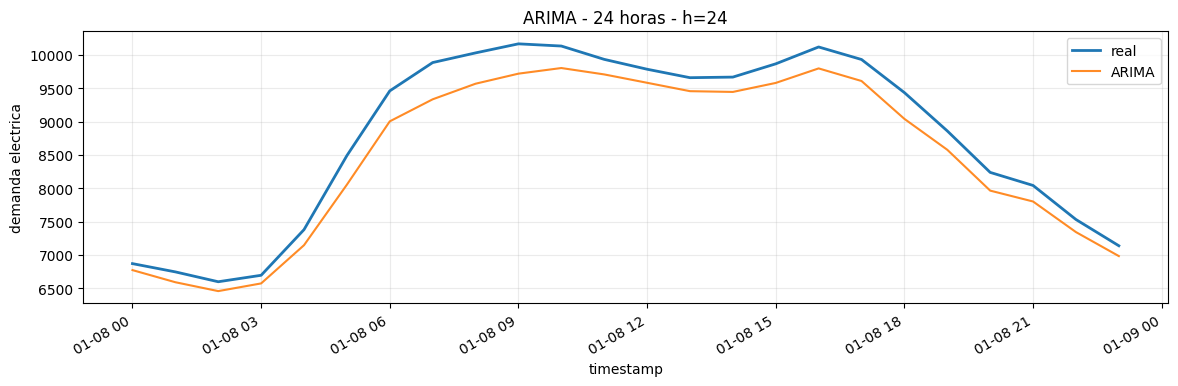

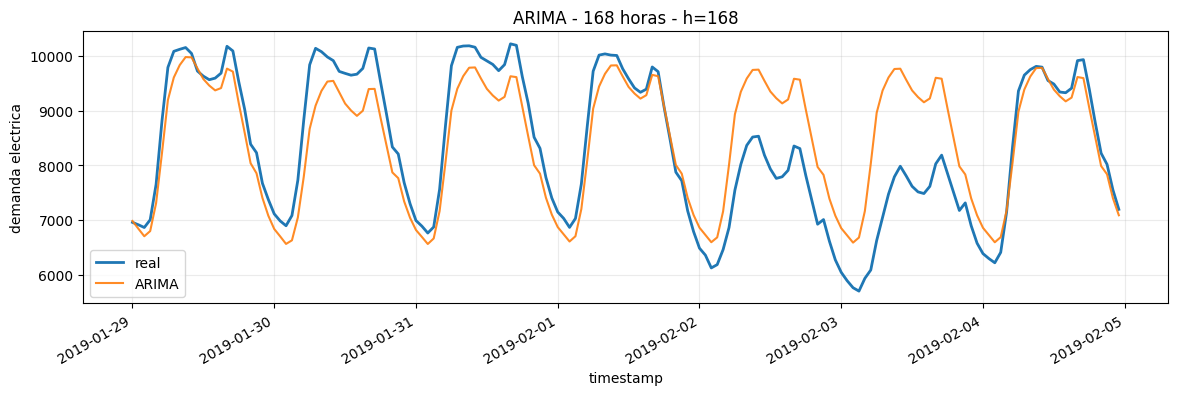

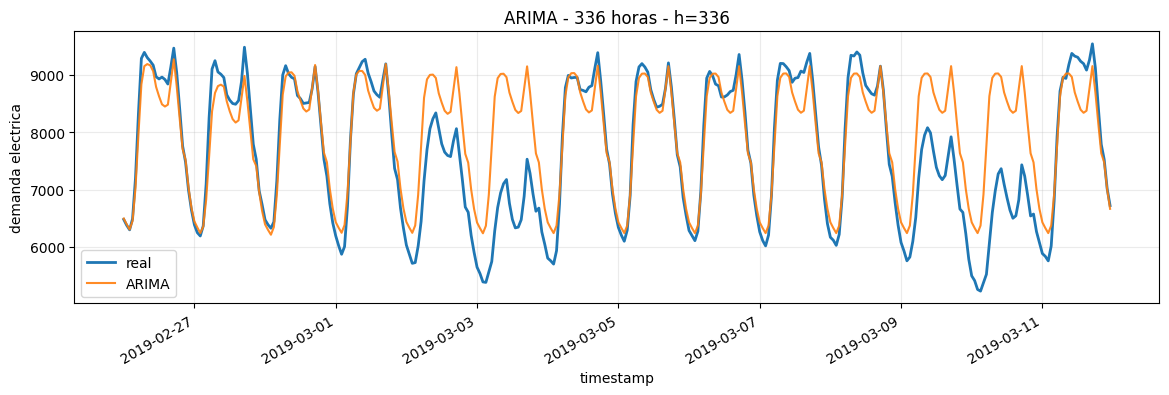

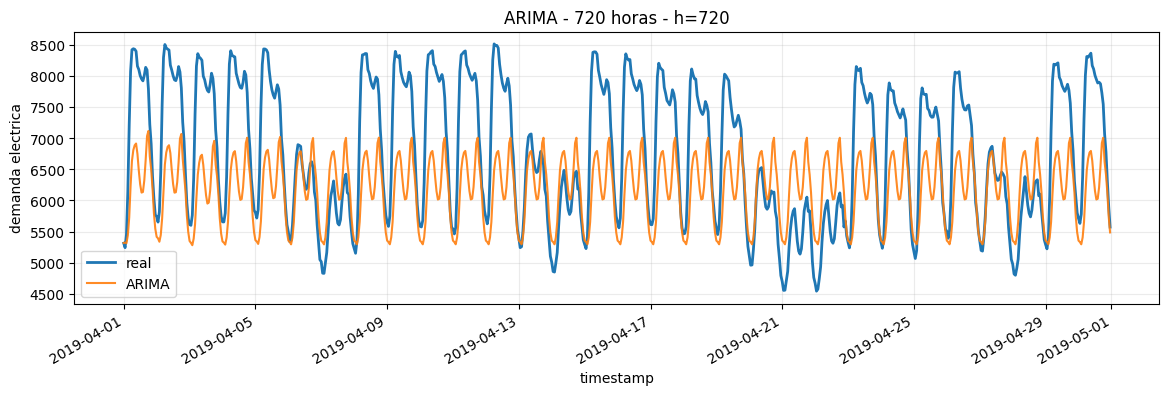

In [7]:
for forecast in forecasts:
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(forecast["timestamp"], forecast["y"], label="real", linewidth=2)
    ax.plot(forecast["timestamp"], forecast["yhat"], label="ARIMA", alpha=0.9)
    ax.set_title(f"ARIMA - {forecast['label'].iloc[0]} - h={int(forecast['horizon'].iloc[0])}")
    ax.set_xlabel("timestamp")
    ax.set_ylabel("demanda electrica")
    ax.legend()
    ax.grid(alpha=0.25)
    fig.autofmt_xdate()
    plt.show()
